# Point-in-Time Leakage Experiment

Notebook này trình bày trực tiếp toàn bộ model research flow: feature exploration, temporal split, Dummy baseline, ba LightGBM experiment, metric comparison và evaluation visualization. SQL/PIT dataset preparation được tái sử dụng từ package; model initialization, `fit`, `predict_proba` và metrics không bị giấu sau một wrapper đơn khối.

## 1. Experiment Objective

PIT-correct features chỉ dùng event trong **`[cutoff - window, cutoff)`**: bao gồm biên dưới, loại event tại cutoff và mọi event tương lai. Future-looking features cố ý dùng **`(cutoff, cutoff + window]`** để mô phỏng leakage. Mục tiêu không phải chứng minh future-only luôn có metric cao hơn; mục tiêu là đo rủi ro khi thông tin chưa tồn tại tại prediction time lọt vào model. Controlled comparison chính là PIT so với PIT + future.

In [1]:
from pathlib import Path
import sys

import duckdb
from lightgbm import LGBMClassifier
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)

project_root = Path.cwd()
if project_root.name == 'notebooks':
    project_root = project_root.parent
if not (project_root / 'src' / 'pit_feature_store').exists():
    project_root = project_root.parent

src_path = project_root / 'src'
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from pit_feature_store.leakage import (
    prepare_experiment_frames,
    temporal_masks,
)

database_path = project_root / 'artifacts' / 'warehouse.duckdb'
catalog_path = project_root / 'config' / 'feature_catalog.yaml'
report_dir = project_root / 'artifacts' / 'reports'
metrics_path = report_dir / 'leakage_metrics.csv'
markdown_path = report_dir / 'leakage_experiment.md'
random_state = 42
train_fraction = 0.8

if not database_path.exists():
    raise FileNotFoundError(
        'Chưa có warehouse. Hãy chạy scripts/init_warehouse.py và offline engine trước.'
    )
plt.style.use('seaborn-v0_8-whitegrid')
database_path

WindowsPath('C:/Users/tiennd49/Documents/point-in-time-feature-store/artifacts/warehouse.duckdb')

### Reusable data preparation

Cell này chỉ gọi reusable data/PIT logic: tạo future dataset, lọc cohort đủ observation window, chọn split timestamp và load ba DataFrame có cùng label spine. Không train model trong module call này.

In [2]:
connection = duckdb.connect(database_path.as_posix())
try:
    prepared = prepare_experiment_frames(
        connection, catalog_path, train_fraction=train_fraction
    )
finally:
    connection.close()

catalog = prepared['catalog']
bounds = prepared['bounds']
split_ts = prepared['split_ts']
pit_columns = prepared['pit_columns']
future_columns = prepared['future_columns']
augmented_columns = prepared['augmented_columns']
frames = prepared['frames']

{name: frame.shape for name, frame in frames.items()}

{'pit': (370770, 8),
 'future_only': (370770, 8),
 'pit_plus_future': (370770, 12)}

## 2. Features Used

`future_only` giữ tên bốn PIT feature để đáp ứng schema experiment; bảng dưới làm rõ semantic mapping trong controlled PIT + future dataset.

In [3]:
feature_table = pd.DataFrame(
    {
        'pit_feature': [feature.name for feature in catalog.features],
        'description': [feature.description for feature in catalog.features],
        'aggregation': [feature.aggregation for feature in catalog.features],
        'window_hours': [feature.window_hours for feature in catalog.features],
        'future_feature': future_columns,
    }
)
display(feature_table)

,pit_feature,description,aggregation,window_hours,future_feature
0,sum_amt_24h,Tổng giá trị giao dịch của uid trong 24 giờ tr...,sum,24,future_sum_amt_24h
1,count_txn_24h,Số giao dịch của uid trong 24 giờ trước cutoff.,count,24,future_count_txn_24h
2,sum_amt_7d,Tổng giá trị giao dịch của uid trong 7 ngày tr...,sum,168,future_sum_amt_7d
3,time_since_last_txn_sec,Số giây từ giao dịch gần nhất của uid trong 72...,time_since_last,720,time_to_next_txn_sec


## 3. Feature Exploration

Mỗi feature được clip tại p99 chỉ cho visualization. `log1p` được dùng cho các feature liên tục/skew; DataFrame dùng để train không bị chỉnh sửa. Fraud và non-fraud được overlay để nhìn distribution trước khi fit model.

,count,mean,std,min,25%,50%,75%,95%,99%,max,missing_pct
sum_amt_24h,370770.0,412.399998,1053.707091,0.0,0.0,0.00,312.4500,2254.84,5.226188e+03,69654.232,0.000000
count_txn_24h,370770.0,2.981101,6.375025,0.0,0.0,0.00,3.0000,16.00,3.300000e+01,87.000,0.000000
sum_amt_7d,370770.0,2570.386540,5796.061155,0.0,0.0,329.95,2176.3675,13889.71,3.229534e+04,69654.232,0.000000
time_since_last_txn_sec,296618.0,246787.620515,461803.213722,1.0,4459.0,48768.50,245567.2500,1308323.00,2.255780e+06,2591903.000,19.999461


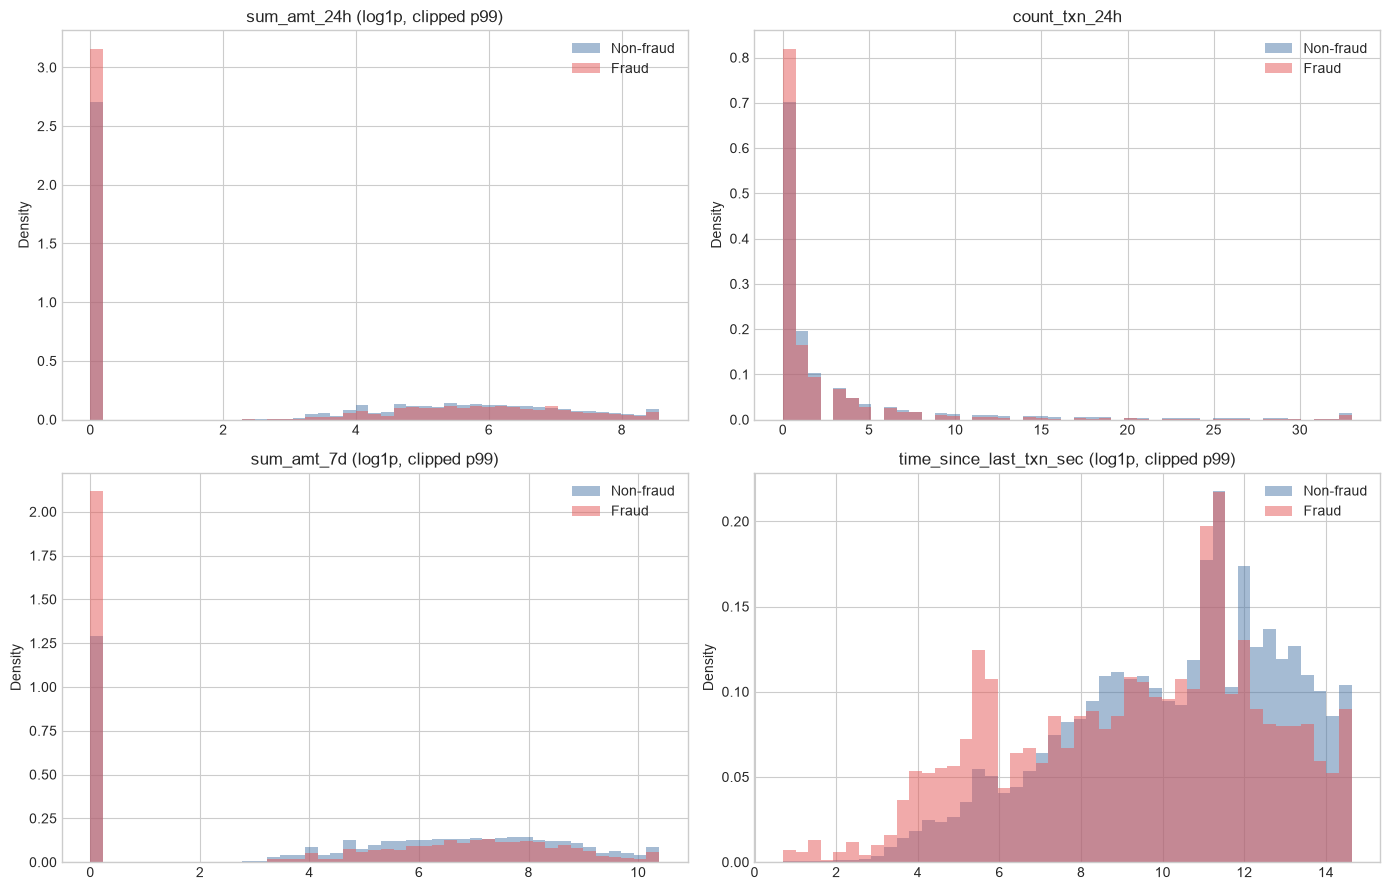

In [4]:
pit_frame = frames['pit']
plot_frame = pit_frame.sample(
    n=min(100_000, len(pit_frame)),
    random_state=random_state,
)
feature_summary = pit_frame[pit_columns].describe(
    percentiles=[0.25, 0.5, 0.75, 0.95, 0.99]
).T
feature_summary['missing_pct'] = 100.0 * pit_frame[pit_columns].isna().mean()
display(feature_summary)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, feature in zip(axes.flat, pit_columns, strict=True):
    upper = pit_frame[feature].quantile(0.99)
    for label, color, name in [(0, '#4C78A8', 'Non-fraud'), (1, '#E45756', 'Fraud')]:
        values = plot_frame.loc[plot_frame['label'] == label, feature].dropna()
        values = values.clip(upper=upper)
        if feature != 'count_txn_24h':
            values = np.log1p(values.clip(lower=0))
        ax.hist(values, bins=45, density=True, alpha=0.5, color=color, label=name)
    suffix = '' if feature == 'count_txn_24h' else ' (log1p, clipped p99)'
    ax.set_title(feature + suffix)
    ax.set_ylabel('Density')
    ax.legend()
plt.tight_layout()
plt.show()

## 4. Temporal Split

Cohort chỉ giữ cutoff có đủ 720 giờ quan sát ở cả hai phía. Train dùng `cutoff_ts < split_ts`; test dùng `cutoff_ts >= split_ts`, nên các giao dịch cùng timestamp không bị chia sang hai tập. Không dùng random split vì production prediction diễn ra về phía tương lai.

In [5]:
train_mask, test_mask = temporal_masks(pit_frame, split_ts)
train_labels = pit_frame.loc[train_mask, 'label'].astype(int)
test_labels = pit_frame.loc[test_mask, 'label'].astype(int)

cohort_summary = pd.DataFrame(
    [{
        'eligible_start': bounds.start,
        'eligible_end': bounds.end,
        'total_rows': bounds.total_rows,
        'eligible_rows': bounds.eligible_rows,
        'excluded_rows': bounds.excluded_rows,
        'split_ts': split_ts,
    }]
)
split_summary = pd.DataFrame(
    [
        {
            'partition': 'train',
            'rows': int(train_mask.sum()),
            'fraud_count': int(train_labels.sum()),
            'fraud_rate': float(train_labels.mean()),
            'start': pit_frame.loc[train_mask, 'cutoff_ts'].min(),
            'end': pit_frame.loc[train_mask, 'cutoff_ts'].max(),
        },
        {
            'partition': 'test',
            'rows': int(test_mask.sum()),
            'fraud_count': int(test_labels.sum()),
            'fraud_rate': float(test_labels.mean()),
            'start': pit_frame.loc[test_mask, 'cutoff_ts'].min(),
            'end': pit_frame.loc[test_mask, 'cutoff_ts'].max(),
        },
    ]
)
display(cohort_summary)
display(split_summary)

,eligible_start,eligible_end,total_rows,eligible_rows,excluded_rows,split_ts
0,2018-01-01,2018-05-02 23:58:51,590540,370770,219770,2018-04-05 23:19:56


,partition,rows,fraud_count,fraud_rate,start,end
0,train,296615,11741,0.039583,2018-01-01 00:00:05,2018-04-05 23:19:51
1,test,74155,2527,0.034077,2018-04-05 23:19:56,2018-05-02 23:58:49


## 5. Baseline Model

Dummy baseline dùng class prior của train set và không nhận feature nghiệp vụ. Với score hằng số, ROC-AUC xấp xỉ 0.5 và PR-AUC bằng prevalence fraud của test set.

In [6]:
metric_rows = []
prediction_frames = []

def record_evaluation(model_name, dataset_name, columns, frame, mask, probabilities):
    labels = frame.loc[mask, 'label'].astype(int)
    roc_auc = float(roc_auc_score(labels, probabilities))
    pr_auc = float(average_precision_score(labels, probabilities))
    test_fraud_rate = float(labels.mean())
    row = {
        'model': model_name,
        'dataset': dataset_name,
        'eligible_start': bounds.start.isoformat(sep=' '),
        'eligible_end': bounds.end.isoformat(sep=' '),
        'total_rows': bounds.total_rows,
        'eligible_rows': bounds.eligible_rows,
        'excluded_rows': bounds.excluded_rows,
        'split_ts': split_ts.isoformat(sep=' '),
        'train_rows': int(train_mask.sum()),
        'test_rows': int(mask.sum()),
        'train_positive': int(train_labels.sum()),
        'test_positive': int(labels.sum()),
        'train_fraud_rate': float(train_labels.mean()),
        'test_fraud_rate': test_fraud_rate,
        'feature_count': len(columns),
        'feature_columns': '|'.join(columns),
        'roc_auc': roc_auc,
        'pr_auc': pr_auc,
        'pr_auc_lift': pr_auc / test_fraud_rate,
    }
    predictions = frame.loc[mask, ['label_id', 'cutoff_ts', 'label']].copy()
    predictions['dataset'] = dataset_name
    predictions['model'] = model_name
    predictions['score'] = probabilities
    metric_rows.append(row)
    prediction_frames.append(predictions)
    return row

dummy_model = DummyClassifier(strategy='prior')
dummy_model.fit(np.zeros((len(train_labels), 1)), train_labels)
dummy_probabilities = dummy_model.predict_proba(
    np.zeros((len(test_labels), 1))
)[:, 1]
dummy_result = record_evaluation(
    'Dummy baseline', 'dummy_baseline', [], pit_frame, test_mask,
    dummy_probabilities,
)
display(pd.DataFrame([dummy_result]))

,model,dataset,eligible_start,eligible_end,total_rows,eligible_rows,excluded_rows,split_ts,train_rows,test_rows,train_positive,test_positive,train_fraud_rate,test_fraud_rate,feature_count,feature_columns,roc_auc,pr_auc,pr_auc_lift
0,Dummy baseline,dummy_baseline,2018-01-01 00:00:00,2018-05-02 23:58:51,590540,370770,219770,2018-04-05 23:19:56,296615,74155,11741,2527,0.039583,0.034077,0,,0.5,0.034077,1.0


## 6. PIT LightGBM

Helper nhỏ bên dưới chỉ tránh lặp code giữa ba experiment. Việc khởi tạo LightGBM, `fit`, `predict_proba` và metric call đều xuất hiện trực tiếp trong notebook. Parameters giữ nguyên experiment đã được duyệt để metric có thể so sánh.

In [7]:
def fit_lightgbm_experiment(model_name, dataset_name, frame, columns):
    current_train_mask, current_test_mask = temporal_masks(frame, split_ts)
    y_train = frame.loc[current_train_mask, 'label'].astype(int)

    model = LGBMClassifier(
        objective='binary',
        n_estimators=100,
        random_state=random_state,
        n_jobs=-1,
        deterministic=True,
        force_col_wise=True,
        verbosity=-1,
    )
    model.fit(frame.loc[current_train_mask, columns], y_train)
    probabilities = model.predict_proba(
        frame.loc[current_test_mask, columns]
    )[:, 1]
    result = record_evaluation(
        model_name, dataset_name, columns, frame, current_test_mask,
        probabilities,
    )
    return model, result

pit_model, pit_result = fit_lightgbm_experiment(
    'PIT LightGBM', 'pit', frames['pit'], pit_columns
)
display(pd.DataFrame([pit_result]))

,model,dataset,eligible_start,eligible_end,total_rows,eligible_rows,excluded_rows,split_ts,train_rows,test_rows,train_positive,test_positive,train_fraud_rate,test_fraud_rate,feature_count,feature_columns,roc_auc,pr_auc,pr_auc_lift
0,PIT LightGBM,pit,2018-01-01 00:00:00,2018-05-02 23:58:51,590540,370770,219770,2018-04-05 23:19:56,296615,74155,11741,2527,0.039583,0.034077,4,sum_amt_24h|count_txn_24h|sum_amt_7d|time_sinc...,0.679783,0.067894,1.992364


## 7. Future-only Model

Model này thay toàn bộ historical signal bằng future-looking values trên cùng label spine và temporal split. Đây là leakage experiment theo specification, không phải model hợp lệ cho production.

In [8]:
future_model, future_result = fit_lightgbm_experiment(
    'Future-only LightGBM',
    'future_only',
    frames['future_only'],
    pit_columns,
)
display(pd.DataFrame([future_result]))

,model,dataset,eligible_start,eligible_end,total_rows,eligible_rows,excluded_rows,split_ts,train_rows,test_rows,train_positive,test_positive,train_fraud_rate,test_fraud_rate,feature_count,feature_columns,roc_auc,pr_auc,pr_auc_lift
0,Future-only LightGBM,future_only,2018-01-01 00:00:00,2018-05-02 23:58:51,590540,370770,219770,2018-04-05 23:19:56,296615,74155,11741,2527,0.039583,0.034077,4,sum_amt_24h|count_txn_24h|sum_amt_7d|time_sinc...,0.674214,0.064931,1.905402


## 8. PIT + Future Model

Controlled comparison thêm bốn future features vào đúng bốn PIT features. So với PIT model, khác biệt chính là quyền truy cập thông tin tương lai.

In [9]:
augmented_model, augmented_result = fit_lightgbm_experiment(
    'PIT + future LightGBM',
    'pit_plus_future',
    frames['pit_plus_future'],
    augmented_columns,
)
display(pd.DataFrame([augmented_result]))

,model,dataset,eligible_start,eligible_end,total_rows,eligible_rows,excluded_rows,split_ts,train_rows,test_rows,train_positive,test_positive,train_fraud_rate,test_fraud_rate,feature_count,feature_columns,roc_auc,pr_auc,pr_auc_lift
0,PIT + future LightGBM,pit_plus_future,2018-01-01 00:00:00,2018-05-02 23:58:51,590540,370770,219770,2018-04-05 23:19:56,296615,74155,11741,2527,0.039583,0.034077,8,sum_amt_24h|count_txn_24h|sum_amt_7d|time_sinc...,0.705485,0.074536,2.187256


## 9. Model Comparison

In [10]:
metrics = pd.DataFrame(metric_rows)
predictions = pd.concat(prediction_frames, ignore_index=True)
model_comparison = metrics[[
    'model', 'feature_count', 'roc_auc', 'pr_auc', 'pr_auc_lift'
]].copy()
display(model_comparison)

indexed = metrics.set_index('dataset')
controlled_comparison = pd.DataFrame(
    [{
        'comparison': 'PIT + future minus PIT',
        'roc_auc_delta': (
            indexed.loc['pit_plus_future', 'roc_auc']
            - indexed.loc['pit', 'roc_auc']
        ),
        'pr_auc_delta': (
            indexed.loc['pit_plus_future', 'pr_auc']
            - indexed.loc['pit', 'pr_auc']
        ),
    }]
)
display(controlled_comparison)

,model,feature_count,roc_auc,pr_auc,pr_auc_lift
0,Dummy baseline,0,0.500000,0.034077,1.000000
1,PIT LightGBM,4,0.679783,0.067894,1.992364
2,Future-only LightGBM,4,0.674214,0.064931,1.905402
3,PIT + future LightGBM,8,0.705485,0.074536,2.187256


,comparison,roc_auc_delta,pr_auc_delta
0,PIT + future minus PIT,0.025702,0.006641


## 10. Evaluation Visualization

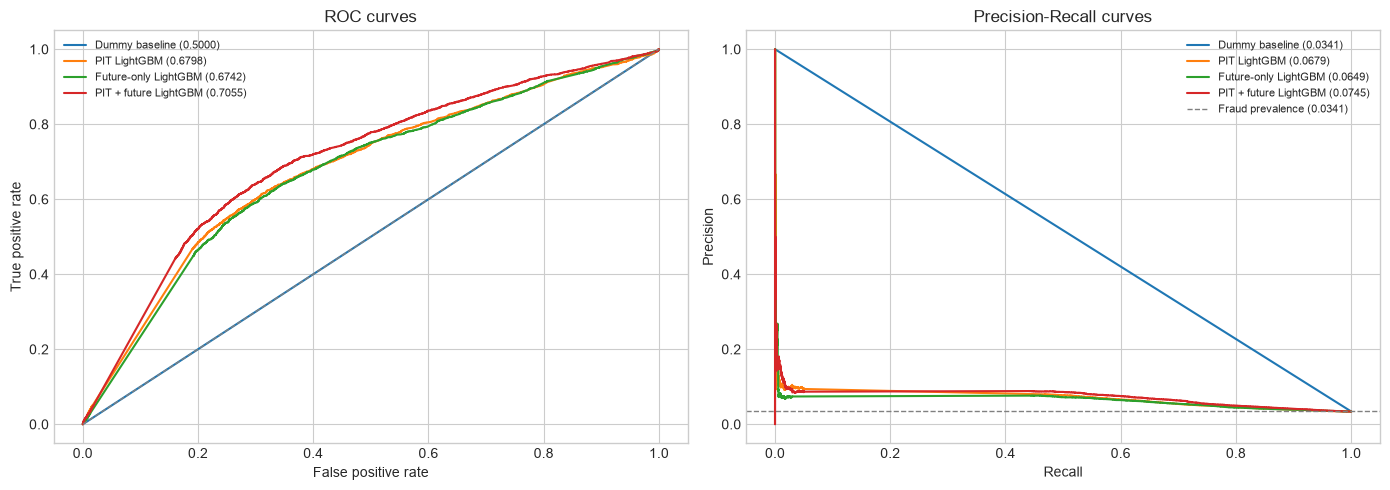

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for dataset_name, group in predictions.groupby('dataset', sort=False):
    metric_row = indexed.loc[dataset_name]
    fpr, tpr, _ = roc_curve(group['label'], group['score'])
    precision, recall, _ = precision_recall_curve(group['label'], group['score'])
    axes[0].plot(
        fpr, tpr,
        label=f"{metric_row['model']} ({metric_row['roc_auc']:.4f})",
    )
    axes[1].plot(
        recall, precision,
        label=f"{metric_row['model']} ({metric_row['pr_auc']:.4f})",
    )

axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1)
axes[0].set_title('ROC curves')
axes[0].set_xlabel('False positive rate')
axes[0].set_ylabel('True positive rate')
axes[0].legend(fontsize=8)

prevalence = float(test_labels.mean())
axes[1].axhline(
    prevalence, linestyle='--', color='gray', linewidth=1,
    label=f'Fraud prevalence ({prevalence:.4f})',
)
axes[1].set_title('Precision-Recall curves')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

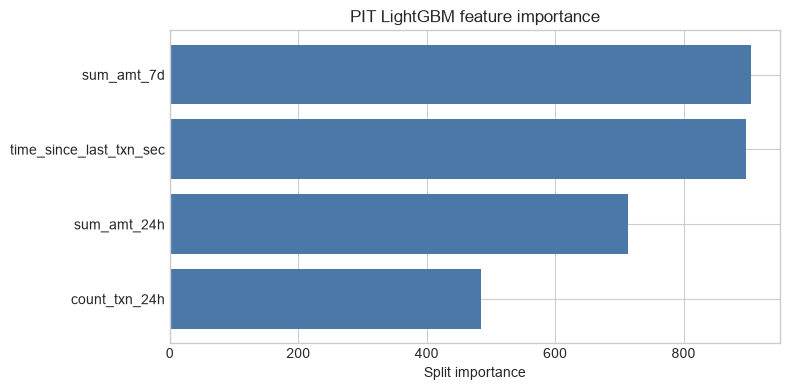

,feature,importance
2,sum_amt_7d,905
3,time_since_last_txn_sec,897
0,sum_amt_24h,714
1,count_txn_24h,484


In [12]:
pit_importance = pd.DataFrame(
    {
        'feature': pit_columns,
        'importance': pit_model.feature_importances_,
    }
).sort_values('importance')

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(pit_importance['feature'], pit_importance['importance'], color='#4C78A8')
ax.set_title('PIT LightGBM feature importance')
ax.set_xlabel('Split importance')
plt.tight_layout()
plt.show()
display(pit_importance.sort_values('importance', ascending=False))

## 11. Conclusion

- PIT LightGBM chỉ dùng thông tin tồn tại trước cutoff theo `[cutoff - window, cutoff)`.
- Future-only là thí nghiệm leakage có chủ đích và không hợp lệ cho production prediction.
- Future-only không bắt buộc tốt hơn PIT vì nó thay thế past signal thay vì chỉ bổ sung thông tin.
- Controlled comparison quan trọng hơn là PIT so với PIT + future: hai model cùng có PIT signal, model thứ hai được thêm future signal.
- Dù metric tăng hay giảm trên một lần chạy, dữ liệu tương lai tuyệt đối không được xuất hiện trong feature phục vụ production.

### Export reproducible results

Metrics được ghi trực tiếp từ các giá trị vừa tính; không hard-code kết quả.

In [13]:
report_dir.mkdir(parents=True, exist_ok=True)
metrics.to_csv(metrics_path, index=False, float_format='%.10f')

comparison_rows = '\n'.join(
    f"| {row.model} | {row.feature_count} | {row.roc_auc:.6f} | {row.pr_auc:.6f} |"
    for row in model_comparison.itertuples(index=False)
)
controlled_row = controlled_comparison.iloc[0]
report_markdown = f"""# Leakage experiment

- Eligible cohort: `{bounds.start}` to `{bounds.end}`
- Temporal split: train `< {split_ts}`, test `>= {split_ts}`
- PIT semantics: `[cutoff - window, cutoff)`
- Future semantics: `(cutoff, cutoff + window]`

| Model | Feature count | ROC-AUC | PR-AUC |
|---|---:|---:|---:|
{comparison_rows}

Controlled PIT + future minus PIT: ROC-AUC `{controlled_row['roc_auc_delta']:+.6f}`, PR-AUC `{controlled_row['pr_auc_delta']:+.6f}`.

Future-only is an intentional leakage experiment. Future data is forbidden in production predictions.
"""
markdown_path.write_text(report_markdown, encoding='utf-8')

exported_metrics = pd.read_csv(metrics_path)
assert len(exported_metrics) == 4
assert set(exported_metrics['dataset']) == {
    'dummy_baseline', 'pit', 'future_only', 'pit_plus_future'
}
print(f'Đã ghi metrics: {metrics_path}')
print(f'Đã ghi report: {markdown_path}')

Đã ghi metrics: C:\Users\tiennd49\Documents\point-in-time-feature-store\artifacts\reports\leakage_metrics.csv
Đã ghi report: C:\Users\tiennd49\Documents\point-in-time-feature-store\artifacts\reports\leakage_experiment.md
